In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import rosen, rosen_der
from numpy.random import default_rng

%load_ext autoreload
%autoreload 2
# from DFO_algorithms import gradient_descent
from DFO_utilities import as_column_vec
import DFO_utilities

This notebook documents the implementation of the bi-fidelity gradient-free stochastic subspace descent method (BF-SSD). There are two novel adjustments we propose:
1. We leverage the low-fidelity model to calibrate the limited given high-fidelity evaluations, in order to determine the optimal stepsize for SSD;
2. We apply an extension of SSD method to catch the intrinsic latent space of the given objective function. With the stepsize adjustment from the calibrated bi-fidelity model, we are able to determine the intensity of the given sampled direction.

#### Make a "wrapper" class to record information
The idea is to make it foolproof to correctly record information
  i.e., now you don't have to manually make a logging function

In [2]:
class objectiveFcn:
    """ Note: in numpy, vectors can be of size (n,) or of size (n,1), 
    and the two conventions do not mix well. The convention this code takes
    is that they are of size (n,1) """
    def __init__(self, f,dimension=None, column_vectors = True, errFcn = None, label=None):
        """ 
        'f' is the objective function
        This class will make a 'counter' class to record how
        often it is called """
        self.f = f
        self.fcnHistory = []
        self.errHistory = []
        self.dim = dimension
        self.errFcn = errFcn
        if column_vectors:
            self.vec = DFO_utilities.as_column_vec
        else:
            self.vec = np.asarray
        self.label=label
    def eval(self,x):
        x = self.vec(x)
        fx = self.f(x)
        if isinstance(fx,np.ndarray):
            if fx.size > 1 :
                raise ValueError("Objective Fcn must return a scalar!")
            fx = fx.item() # make sure it is a scalar
        self.fcnHistory.append(fx)
        if self.errFcn is not None:
            self.errHistory.append( self.errFcn(x) )
        if self.dim == None:
            self.dim = x.shape[0]
        elif self.dim != x.size:
            raise ValueError(f'x is not the right size, is {x.size}, expecting {self.dim}')
        return fx
    def directionalDerivative(self,x,p, return_fx = False ):
        deriv, fx = DFO_utilities.directionalDerivative(x,p,self.eval)
        deriv = self.vec(deriv)
        if return_fx:
            return deriv, fx
        else:
            return deriv
    def gradient(self,x, return_fx = False):
        """ Finds gradient via finite-differences """
        deriv, fx = DFO_utilities.gradient(x,self.eval)
        deriv = self.vec(deriv)
        if return_fx:
            return deriv, fx
        else:
            return deriv
    def returnHistory(self, return_err = False):
        if (self.errFcn is None)  or  (not return_err) :
            return np.asarray(self.fcnHistory)
        else:
            return np.asarray(self.fcnHistory), np.asarray(self.errHistory)
        
    def returnMinimumHistory(self):
        """ Function evaluation history, but always taking the best-so-far """
        if (self.errFcn is None)  or  (not return_err) :
            return np.minimum.accumulate(np.asarray(self.fcnHistory))
        else:
            return np.minimum.accumulate(np.asarray(self.fcnHistory)), np.minimum.accumulate(np.asarray(self.errHistory))
        
    def reset(self):
        self.fcnHistory = []
        self.errHistory = []
        return


# f    = lambda x : x[0]**2 + 2*x[1]**6 + 3*x[2]**4 + 4*x[3]**4
# f_LF = lambda x : f(x) - 3*x[3]**4

# # Test it...
# obj = objectiveFcn(f)
# x0  = [1.0, 1.0, 1.0, 1.0]

# obj.eval(x0)
# obj.eval(x0)
# obj.gradient(x0)

# fcnHist = obj.returnHistory()
# print(fcnHist)
# print(obj.returnMinimumHistory())
# obj.reset()

### Define some algorithms

In [31]:
def grad_desc(x0,obj,learning_rate=1e-2,num_iterations=1e2, printEvery = None):
    """ Basic gradient descent, using finite differences to estimate gradient """
    print('======== gradient descent ======')
    x = as_column_vec(x0,copy=True)
    if printEvery is None: printEvery = int( num_iterations / 10 )
    obj.reset()
    for i in range(int(num_iterations)):
        gradx,fx = obj.gradient(x, return_fx=True)
        if np.isnan(fx):
            print('Found NaN')
            return x
        x -= learning_rate*gradx
        if not np.mod(i,int(printEvery)):
            print(f'Iter {i:3d}, f(x) is {fx:g}')
    return x

def ssd(x0,obj,learning_rate=1e-2,num_iterations=1e2, printEvery = None,ell=1,obj_lowFi=None, 
        lowFiLinesearch=False,linesearchIter=20, include_lowFi_grad = False, lr_cut=False):
    """ Stochastic Substace Descent of Kozak, Tenorio, Becker, Doostan
    Optionally w/ low-fidelity model for linesearch """
    x = as_column_vec(x0,copy=True)
    n = x.shape[0]
    if printEvery is None: printEvery = int( num_iterations / 10 )
    obj.reset()
    if obj_lowFi is not None:
        obj_lowFi.reset()
        learning_rate_original = learning_rate
    else:
        lowFiLinesearch = False
        include_lowFi_grad = False
    if lowFiLinesearch:  print('======== SSD w/ low-fi linesearch =')
    elif lr_cut:         print('======== SSD w/ lr cut ===========')
    else:                print('======== SSD ===================')
    for i in range(int(num_iterations)):
        if lr_cut and i == 0:
            lowFiLinesearch = True
        if lr_cut and i == 101:
            lowFiLinesearch = False
            learning_rate = 1e-2
        if include_lowFi_grad:
            if ell<=1: raise ValueError("Cannot have ell <= 1 if include_lowFi_grad==True")
            U = DFO_utilities.haar_QR(n,ell-1,ignoreDiagScaling=True,transpose=False)
            u = obj_lowFi.gradient(x,return_fx=False)
            u = u - U@(U.T@u)
            U = np.c_[ U, u/np.linalg.norm(u) ]
        else:
            # Standard SSO
            U = DFO_utilities.haar_QR(n,ell,ignoreDiagScaling=True,transpose=False)
        gradx,fx = obj.directionalDerivative(x,U,return_fx=True)
        p = U @ gradx  # projected gradient
        if lowFiLinesearch:
            step_sizes = learning_rate_original * np.logspace(-2,2,num=linesearchIter) # one way to do it
            # step_sizes = learning_rate * np.logspace(-2,2,num=linesearchIter) # another way to do it, but often then gets stuck at tiny steps
            fVals = [obj_lowFi.eval(x.ravel() - step_size * p.ravel() ) for step_size in step_sizes]
            learning_rate =  step_sizes[np.argmin(fVals)]

        x -= learning_rate*p
        if not np.mod(i,int(printEvery)):
            print(f'Iter {i:3d}, f(x) is {fx:g}')
        
    return x


def lowfi_gradDescent(x0,obj,learning_rate=1e-2,num_iterations=1e2, printEvery = None,obj_lowFi=None, 
        linesearchIter=20):
    """ Gradient descent using low-fidelity model, but with high-fidelity for lineserach  
    This DOES NOT WORK WELL """
    x = as_column_vec(x0,copy=True)
    n = x.shape[0]
    if printEvery is None: printEvery = int( num_iterations / 10 )
    obj.reset()
    obj_lowFi.reset()
    if obj_lowFi is None: raise ValueError('Must supply low fidelity objective')
    learning_rate_original = learning_rate
    print('======== low-fi grad desc, high-fi lineseach =')
    for i in range(int(num_iterations)):
        gradx = obj_lowFi.gradient(x,return_fx=False)

        step_sizes = learning_rate_original * np.logspace(-2,2,num=linesearchIter) # one way to do it
        # step_sizes = learning_rate * np.logspace(-2,2,num=linesearchIter) # another way to do it, but often then gets stuck at tiny steps
        fVals = [obj.eval(x.ravel() - step_size * gradx.ravel() ) for step_size in step_sizes]
        learning_rate =  step_sizes[np.argmin(fVals)]
        fx = np.amin(fVals)
        x -= learning_rate*gradx
        if not np.mod(i,int(printEvery)):
            print(f'Iter {i:3d}, f(x) is {fx:g}')
    return x

### Choose an objective function

In [57]:
def f_lr(x, lbd, r):
    if r > len(x):
        raise ValueError('r must be less than or equal to the length of x')
    sums = (x[0]**2 + sum((x[i] - x[i+1])**2 for i in range(0, r-1)) + x[r-1]**2)/2 - x[0]# + 1e-3 * sum(x[i]**2 for i in range(r, len(x)))
    return lbd * sums/4 + 0.12

f    = lambda x : f_lr(x, 1, 20)
f_LF = lambda x : f_lr(x, 1, 10)
x0  = np.random.randn(100)

obj = objectiveFcn(f,label='Low-rank Function')
obj_lowFi= objectiveFcn(f_LF)

In [50]:
# f = rosen  # any dimension
# d  = 100
# x0 = 1/2*np.ones((d,))

# # rosen is sum(100.0*(x[1:] - x[:-1]**2.0)**2
# f_LF = lambda x : np.abs(np.sum(100.0*(x[1:] - x[:-1]**2)**2)) # make it abs linear

# obj = objectiveFcn(f,label=f'Rosenbrock, dim={d}')
# obj_lowFi= objectiveFcn(f_LF)

In [51]:
# d  = 100
# x0 = 1/2*np.ones((d,))

# rng = default_rng()
# n   = d+50
# A   = rng.standard_normal(size=(n,d))
# kappa = np.linalg.cond(A)
# print(f"Condition number of quadratic is {kappa**2}")
# A   /= np.linalg.norm(A,ord=2)  # so a stepsize of 1 should work
# b   = rng.standard_normal(size=(A.shape[0],))
# xOpt = np.linalg.lstsq(A,b,rcond=None)[0]
# fOpt = np.linalg.norm(A@xOpt - b)**2/2
# def f_quad(x):
#     Ab = A@x
#     r  = as_column_vec(Ab) - as_column_vec(b)
#     return np.linalg.norm(r)**2/2 - fOpt  # subtract off
# def grad_quad(x):
#     Ab = A@x
#     r  = as_column_vec(Ab) - as_column_vec(b)
#     return (A.T@r).ravel()

# m = int(n/2) # number of rows to sub-sample
# static_subsample = rng.choice(n,m,replace=False)
# def f_lowFi_static(x):
#     """ Low-fidelity model created by subsampling the rows of the linear system
#     This uses the *same* rows every time it is called
#     """
#     Ab = A@x
#     r  = as_column_vec(Ab) - as_column_vec(b)
#     return np.linalg.norm(r[static_subsample])**2/2 - fOpt

# def f_lowFi_dynamic(x):
#     """ Low-fidelity model created by subsampling the rows of the linear system
#     This uses *different* random rows every time it is called
#     """
#     Ab = A@x
#     r  = as_column_vec(Ab) - as_column_vec(b)
#     return np.linalg.norm( rng.choice(r,m,replace=False) )**2/2 - fOpt
    

# obj = objectiveFcn(f_quad, label=f'Least squares, dim={d}' )
# obj_lowFi= objectiveFcn(f_lowFi_static) # works well at first, not for high accuracy
# # obj_lowFi= objectiveFcn(f_lowFi_dynamic) # doesn't work as well

### Run algorithms

======== gradient descent ======
Iter   0, f(x) is 4.62963
Iter  10, f(x) is 1.27025
Iter  20, f(x) is 0.481929
Iter  30, f(x) is 0.235329
Iter  40, f(x) is 0.138426
Iter  50, f(x) is 0.0936321
Iter  60, f(x) is 0.0700969
Iter  70, f(x) is 0.0562452
Iter  80, f(x) is 0.0472272
Iter  90, f(x) is 0.0408457
======== SSD ===================
Iter   0, f(x) is 4.62963
Iter  10, f(x) is 3.15516e+07
Iter  20, f(x) is 6.04848e+14
Iter  30, f(x) is 1.17468e+22
Iter  40, f(x) is 2.28768e+29
Iter  50, f(x) is 4.45855e+36
Iter  60, f(x) is 8.6914e+43
Iter  70, f(x) is 1.69442e+51
Iter  80, f(x) is 3.30343e+58
Iter  90, f(x) is 6.44048e+65
======== SSD w/ low-fi linesearch =
Iter   0, f(x) is 4.62963
Iter  10, f(x) is 0.0201978
Iter  20, f(x) is 0.00801972
Iter  30, f(x) is 0.00659474
Iter  40, f(x) is 0.00651414
Iter  50, f(x) is 0.00522565
Iter  60, f(x) is 0.00508539
Iter  70, f(x) is 0.00499988
Iter  80, f(x) is 0.00494245
Iter  90, f(x) is 0.00489949
======== SSD w/ low-fi linesearch =
Iter   0

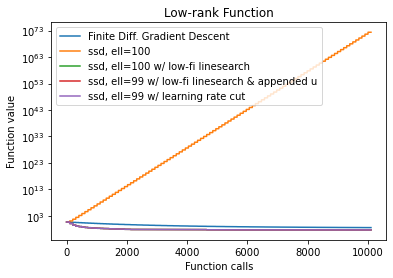

In [59]:
d   = len(x0)
learning_rate = 1e-1
if d < 10 :
    ell = 3 # size of ell really affects behavior
    num_iterations = 1e1
else:
    ell = 100
    num_iterations = 1e2
learning_rate_ssd = learning_rate*ell/3
if 'Rosen' in obj.label:
    learning_rate = 1e-3
    learning_rate_ssd = 1e-4
# Gradient Descent
x   = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
fcnHist_gradDesc = obj.returnHistory()
# SSD
x   = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
fcnHist_ssd = obj.returnHistory()
# SSD with linesearch
x   = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
           lowFiLinesearch=True,num_iterations=num_iterations*d/ell, linesearchIter=10 )
fcnHist_ssd_linesearch = obj.returnHistory()
# SSD with linesearch and adding low-fi gradient to U always
x   = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
           lowFiLinesearch=True,num_iterations=num_iterations*d/ell, linesearchIter=10, include_lowFi_grad=True )
fcnHist_ssd_linesearch_appendU = obj.returnHistory()
# SSD with linesearch
x   = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
           lowFiLinesearch=False,num_iterations=num_iterations*d/ell, linesearchIter=10, lr_cut=True )
fcnHist_ssd_linesearch_lr_cut = obj.returnHistory()


# Gradient Descent on low-fi objective, with high-fi for linesearch. Doesn't work well.
# x = lowfi_gradDescent(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations,obj_lowFi=obj_lowFi)
# fcnHist_gd_linesearch = obj.returnHistory()


plt.semilogy(fcnHist_gradDesc, label='Finite Diff. Gradient Descent')
plt.semilogy(fcnHist_ssd, label=f'ssd, ell={ell}')
plt.semilogy(fcnHist_ssd_linesearch, label=f'ssd, ell={ell} w/ low-fi linesearch')
plt.semilogy(fcnHist_ssd_linesearch_appendU, label=f'ssd, ell={ell-1} w/ low-fi linesearch & appended u')
plt.semilogy(fcnHist_ssd_linesearch_lr_cut, label=f'ssd, ell={ell-1} w/ learning rate cut')
# plt.semilogy(fcnHist_gd_linesearch, label=f'Grad. Desc. on low-fi, w/ hi-fi linesearch') # Doesn't work well.
plt.title(obj.label)
plt.xlabel('Function calls'), plt.ylabel('Function value'), plt.legend()
plt.show()


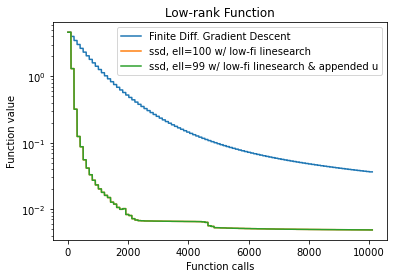

In [61]:
plt.plot(fcnHist_gradDesc, label='Finite Diff. Gradient Descent')
# plt.plot(fcnHist_ssd, label=f'ssd, ell={ell}')
plt.plot(fcnHist_ssd_linesearch, label=f'ssd, ell={ell} w/ low-fi linesearch')
plt.plot(fcnHist_ssd_linesearch_appendU, label=f'ssd, ell={ell-1} w/ low-fi linesearch & appended u')
# plt.semilogy(fcnHist_gd_linesearch, label=f'Grad. Desc. on low-fi, w/ hi-fi linesearch') # Doesn't work well.
plt.title(obj.label)
plt.yscale('log')
plt.xlabel('Function calls'), plt.ylabel('Function value'), plt.legend()
plt.show()